In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('../'))
from src.data_processing import (
    create_lag_features,
    standardize_X,
    standardize_Y,
    create_XY
)

from src.QNN_algo import weatherQNN
from src.trainer import QNNTrainer
from sklearn.metrics import mean_squared_error

file_path = '../data/boston_weather_data_2.csv'
df = pd.read_csv(file_path)

In [9]:
#experiment parameters
candidate_features = ['hum', 'uvi', 'tavg', 'wspd', 'wdir', 'pres', 'prcp']

#select features and lag period for QML
available_features = ['hum', 'tavg', 'wspd']
# available_features: the features we select

LAG_WINDOW = 2

ENTANGLEMENT_TYPE = 1

DEPTH = 1
LEARNING_RATE = 0.01
BATCH_SIZE = 15
VALIDATION_SPLIT = 0.1
EPOCHS = 100

In [10]:
df['target_tomorrow_tavg'] = df['tavg'].shift(-1)

featureCorrelations = df[candidate_features].corrwith(df['target_tomorrow_tavg'], method = 'pearson')
print("the correlation of features with tmr's tavg")
print(featureCorrelations)
print('\n')

feature_corr_matrix = df[candidate_features].corr(method='pearson')

print("the correlation between each feature:")
print(feature_corr_matrix[['hum', 'uvi', 'tavg', 'wspd', 'wdir', 'pres', 'prcp']])

the correlation of features with tmr's tavg
hum     0.889483
uvi     0.787512
tavg    0.958117
wspd   -0.603002
wdir   -0.209369
pres    0.116534
prcp   -0.021052
dtype: float64


the correlation between each feature:
           hum       uvi      tavg      wspd      wdir      pres      prcp
hum   1.000000  0.729129  0.930165 -0.507044 -0.205901 -0.084722  0.129220
uvi   0.729129  1.000000  0.788113 -0.422559 -0.040162  0.082045 -0.166763
tavg  0.930165  0.788113  1.000000 -0.542671 -0.181006 -0.015993  0.032974
wspd -0.507044 -0.422559 -0.542671  1.000000  0.230360 -0.412289  0.087869
wdir -0.205901 -0.040162 -0.181006  0.230360  1.000000 -0.146881 -0.258837
pres -0.084722  0.082045 -0.015993 -0.412289 -0.146881  1.000000 -0.267582
prcp  0.129220 -0.166763  0.032974  0.087869 -0.258837 -0.267582  1.000000


In [11]:


X, Y = create_XY(df, available_features, lag_window = LAG_WINDOW)

correlations = X.corrwith(Y, method = 'pearson')
print("the correlation of each feature_lag with tmr's temp:")
print(correlations)
print(f"# of rows of the dataset: {len(X)}\n")

# if isinstance(Y, pd.DataFrame):
#     y = Y.iloc[:, 0]
# else:
#     y = Y

# tavg_cols = X.filter(like='tavg_lag').columns
# corr = X[tavg_cols].corrwith(y, method='pearson')

# plt.figure(figsize=(10, 4))
# plt.plot(corr.index, corr.values, marker='o')
# plt.xticks(rotation=45)
# plt.xlabel('Lag')
# plt.ylabel('Pearson Correlation')
# plt.title('Pearson Correlation')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

the correlation of each feature_lag with tmr's temp:
hum          0.889163
tavg         0.957965
wspd        -0.602391
hum_lag1     0.840332
hum_lag2     0.822315
tavg_lag1    0.917869
tavg_lag2    0.902852
wspd_lag1   -0.575235
wspd_lag2   -0.550542
dtype: float64
# of rows of the dataset: 666



to what extend the synchronous trands of Tavg and Humidity match:


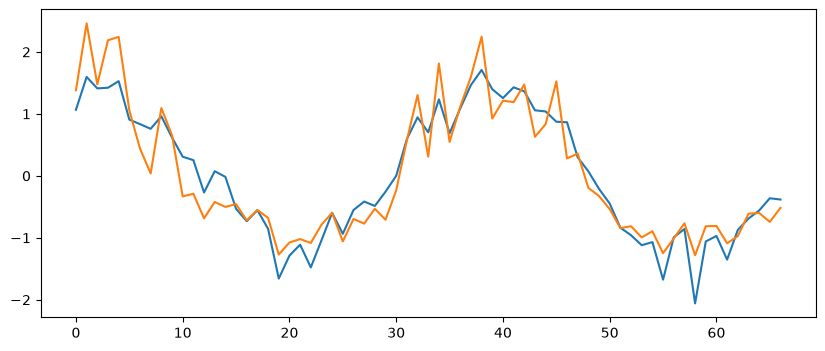

In [5]:
#this is just a demonstration of the trends of Tavg and Humidity
data = pd.read_csv("../data/boston_weather_data_2.csv")
temp = data[["tavg", "hum"]].values

tavg_col = temp[:, 0]
hum_col = temp[:, 1]

tavg_mean = np.mean(tavg_col)
hum_mean = np.mean(hum_col)

tavg_stdev = np.std(tavg_col)
hum_stdev = np.std(hum_col)

tavg_zscr = (temp[:, 0] - tavg_mean) / tavg_stdev
hum_zscr = (temp[:, 1] - hum_mean) / hum_stdev

Z = np.column_stack([tavg_zscr, hum_zscr])

step = 10
Z_plot = Z[::step]

plt.figure(figsize = (10, 4))
plt.plot(Z_plot[:,0], label = 'Tavg')
plt.plot(Z_plot[:,1], label = 'Humidity')

print("to what extend the synchronous trands of Tavg and Humidity match:")
plt.show()

In [12]:
#standardization
X_angle, means, stds, alphas = standardize_X(X, X.columns)

Y_zscr, Y_mean, Y_std = standardize_Y(Y)

print(X_angle.shape)
print(Y_zscr.shape)

(666, 9)
(666,)


In [13]:
#create qnn circuit
model = weatherQNN(
    num_qubits = X_angle.shape[1],
    depth = DEPTH,
    entanglement_type = ENTANGLEMENT_TYPE
)

In [ ]:
# This is a test run on very small batch
X_tiny = X_angle[:8]
Y_tiny = Y_zscr[:8]

model_debug = weatherQNN(num_qubits=X_angle.shape[1], depth=1, entanglement_type=2)
w = np.random.uniform(-0.1, 0.1, size=len(model_debug.weight_params))

for epoch in range(800):
    g = model_debug.grad_batch(w, X_tiny, Y_tiny)
    w -= 0.3 * g
    loss = model_debug.batch_loss(w, X_tiny, Y_tiny)
    if epoch % 20 == 0:
        print(epoch, loss, np.linalg.norm(g))

0 0.37078275540777783 2.9422663686394404
20 0.09765134129786796 0.0017737560409767934


KeyboardInterrupt: 

In [15]:
#train the model
trainer = QNNTrainer(
    model,
    learning_rate = LEARNING_RATE,
    batch_size = BATCH_SIZE,
    validation_split = VALIDATION_SPLIT,
    epochs = EPOCHS
)

weights, history, X_validation, Y_validation = trainer.train(
    X_angle,
    Y_zscr
)

0.6644200636315511
Epoch 0: train=0.978261, val=0.885326
1.2226710584080387
Epoch 1: train=0.973559, val=0.882509
0.48677728366553225
Epoch 2: train=0.971903, val=0.881521
0.8003452874774849
Epoch 3: train=0.974691, val=0.883189
0.27219002709495904
Epoch 4: train=0.974204, val=0.883086
1.2227136929556544
Epoch 5: train=0.969942, val=0.880702
0.22594508183379575
Epoch 6: train=0.970662, val=0.881108
0.0998025780553611
Epoch 7: train=0.970325, val=0.880932
1.0086500354230339
Epoch 8: train=0.967232, val=0.879307
1.2281079145263158
Epoch 9: train=0.963819, val=0.877887
0.1604879684429141
Epoch 10: train=0.963406, val=0.877748
0.05126786630405443
Epoch 11: train=0.963276, val=0.877706
0.780420278590601
Epoch 12: train=0.961565, val=0.877104
0.857293179623358
Epoch 13: train=0.963414, val=0.877783
0.12498416907492949
Epoch 14: train=0.963470, val=0.877867
0.7288510663326216
Epoch 15: train=0.961690, val=0.877328
0.2902885343835679
Epoch 16: train=0.962302, val=0.877547
0.4603375667482516
Ep

{'train_loss': [np.float64(0.9782612347712896), np.float64(0.9735591319599144), np.float64(0.9719028217308633), np.float64(0.9746906714953866), np.float64(0.974203829311705), np.float64(0.969941663000735), np.float64(0.9706618448177297), np.float64(0.970324981656245), np.float64(0.9672319886958822), np.float64(0.9638190967737811), np.float64(0.9634062857636703), np.float64(0.9632759433576067), np.float64(0.9615646276735154), np.float64(0.9634135752603917), np.float64(0.9634700933495522), np.float64(0.9616902793793243), np.float64(0.9623018408133979), np.float64(0.961247249958443), np.float64(0.9601577111397572), np.float64(0.960972900542069), np.float64(0.9600853442183969), np.float64(0.9624663583895549), np.float64(0.9664738750784644), np.float64(0.968557880243772), np.float64(0.9752565854304258), np.float64(0.9749955376434304), np.float64(0.9794609009216133), np.float64(0.9804472174434218), np.float64(0.9838612616061491), np.float64(0.9844551639602866), np.float64(0.9822321186702718)

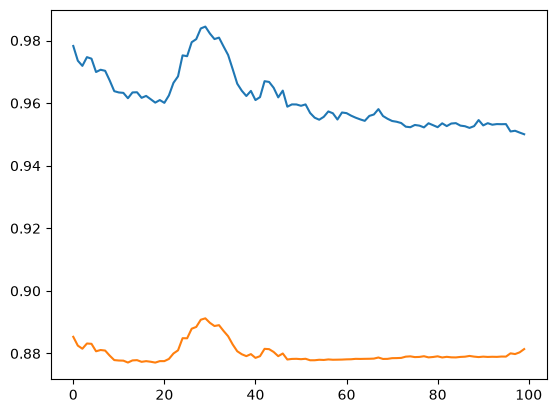

In [16]:
#graph
plt.plot(history['train_loss'])
plt.plot(history['val_loss'])

print(history)
print(len(model.weight_params))

In [17]:
#prediction
predictions = []

for x in X_validation:
    pred = model.forward(x, weights)
    predictions.append(pred)

predictions = np.array(predictions)

pred_temp = predictions*Y_std+Y_mean
true_temp = Y_validation*Y_std+Y_mean

print("Y mean std")
print(Y_zscr.mean(), Y_zscr.std())

print("raw prediction:")
print(f'mean:{predictions.mean()}')
print(f'std:{predictions.std()}')
print(f'min{predictions.min()}')
print(f'max{predictions.max()}')

print("prediction mean:", pred_temp.mean())
print("prediction std:", pred_temp.std())
print("prediction range:", pred_temp.min(), pred_temp.max())

print("corrcoef:", np.corrcoef(predictions, Y_validation)[0,1])

for i in range(20):
    print(
        f'raw_pred{predictions[i]:.2f}.  '
        f'pred = {pred_temp[i]:.2f} Celcius degree  |  '
        f'actual = {true_temp[i]:2f} Celcius degree'
    )

print(np.corrcoef(predictions, true_temp))

Y mean std
-8.5350478769982e-17 1.0
raw prediction:
mean:-0.034062747585026525
std:0.05165867737966595
min-0.09424810924278243
max0.19536474760372582
prediction mean: 8.835202343061733
prediction std: 0.5328850270625248
prediction range: 8.21436031414085 11.201861405662303
corrcoef: 0.31256838743084886
raw_pred-0.04.  pred = 8.81 Celcius degree  |  actual = 20.900000 Celcius degree
raw_pred-0.06.  pred = 8.58 Celcius degree  |  actual = 3.070000 Celcius degree
raw_pred-0.09.  pred = 8.23 Celcius degree  |  actual = 0.690000 Celcius degree
raw_pred-0.06.  pred = 8.58 Celcius degree  |  actual = 2.580000 Celcius degree
raw_pred-0.03.  pred = 8.90 Celcius degree  |  actual = 25.710000 Celcius degree
raw_pred-0.06.  pred = 8.56 Celcius degree  |  actual = 8.430000 Celcius degree
raw_pred-0.07.  pred = 8.49 Celcius degree  |  actual = -3.400000 Celcius degree
raw_pred0.00.  pred = 9.23 Celcius degree  |  actual = 22.330000 Celcius degree
raw_pred-0.06.  pred = 8.57 Celcius degree  |  actual


MSE (Celsius^2): 93.3304
RMSE (Celsius): 9.6608


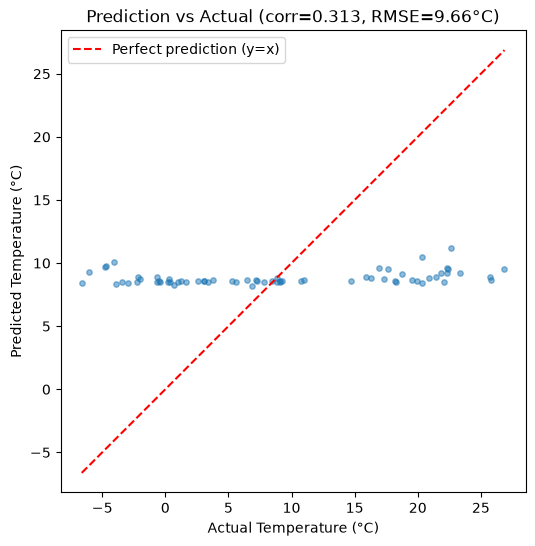

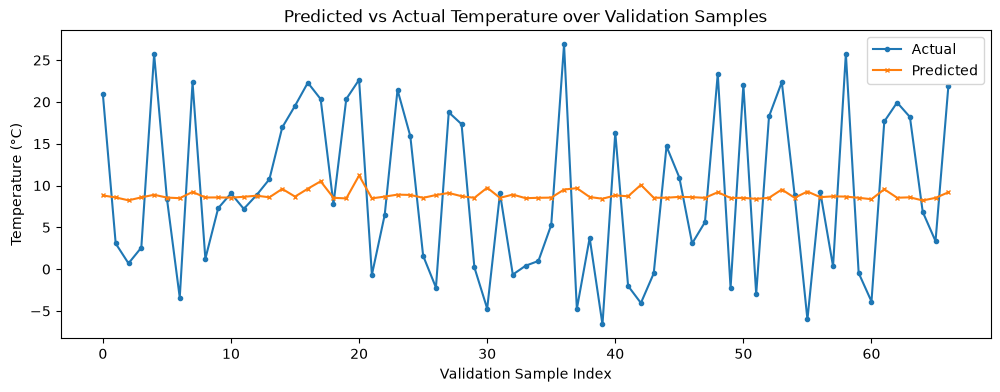

In [18]:


# MSE (基于还原后的真实温度尺度, 单位: 摄氏度平方)
mse_temp = mean_squared_error(true_temp, pred_temp)
rmse_temp = np.sqrt(mse_temp)

print(f"\nMSE (Celsius^2): {mse_temp:.4f}")
print(f"RMSE (Celsius): {rmse_temp:.4f}")

# graph1
plt.figure(figsize=(6, 6))
plt.scatter(true_temp, pred_temp, alpha=0.5, s=15)

lims = [min(true_temp.min(), pred_temp.min()), max(true_temp.max(), pred_temp.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction (y=x)')

plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title(f'Prediction vs Actual (corr={np.corrcoef(predictions, Y_validation)[0,1]:.3f}, RMSE={rmse_temp:.2f}°C)')
plt.legend()
plt.axis('equal')
plt.show()

# graph2
plt.figure(figsize=(12, 4))
plt.plot(true_temp, label='Actual', marker='o', markersize=3)
plt.plot(pred_temp, label='Predicted', marker='x', markersize=3)
plt.xlabel('Validation Sample Index')
plt.ylabel('Temperature (°C)')
plt.title('Predicted vs Actual Temperature over Validation Samples')
plt.legend()
plt.show()